# 🧠 Exercise 2: Naïve Bayesian Classification on Wine Dataset

In this exercise, you will apply the **Naïve Bayes classifier** to a different dataset — the **Wine dataset** — to understand how the algorithm performs on real-world data.

---

## Q1. Import necessary libraries

**Question:** Import all the Python libraries you need for data analysis, visualization, and machine learning.

In [2]:
!pip install seaborn

In [3]:
# Gợi ý: sử dụng numpy, pandas, seaborn, matplotlib, sklearn
# Viết code của bạn tại đây
#import các thư viện cần thiết

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

## Q2. Load the Wine dataset

**Question:** Load the Wine dataset from `sklearn.datasets`, convert it into a DataFrame, and display the first few rows.

In [4]:
# Giải thích: Dùng sklearn.datasets.load_wine() để tải dữ liệu
# Viết code của bạn tại đây

wine = datasets.load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df['class'] = [target_names[i] for i in y]
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


## Q3. Explore the dataset

**Question:** Explore the Wine dataset by showing its structure, basic statistics, and a pairplot to visualize feature relationships.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class

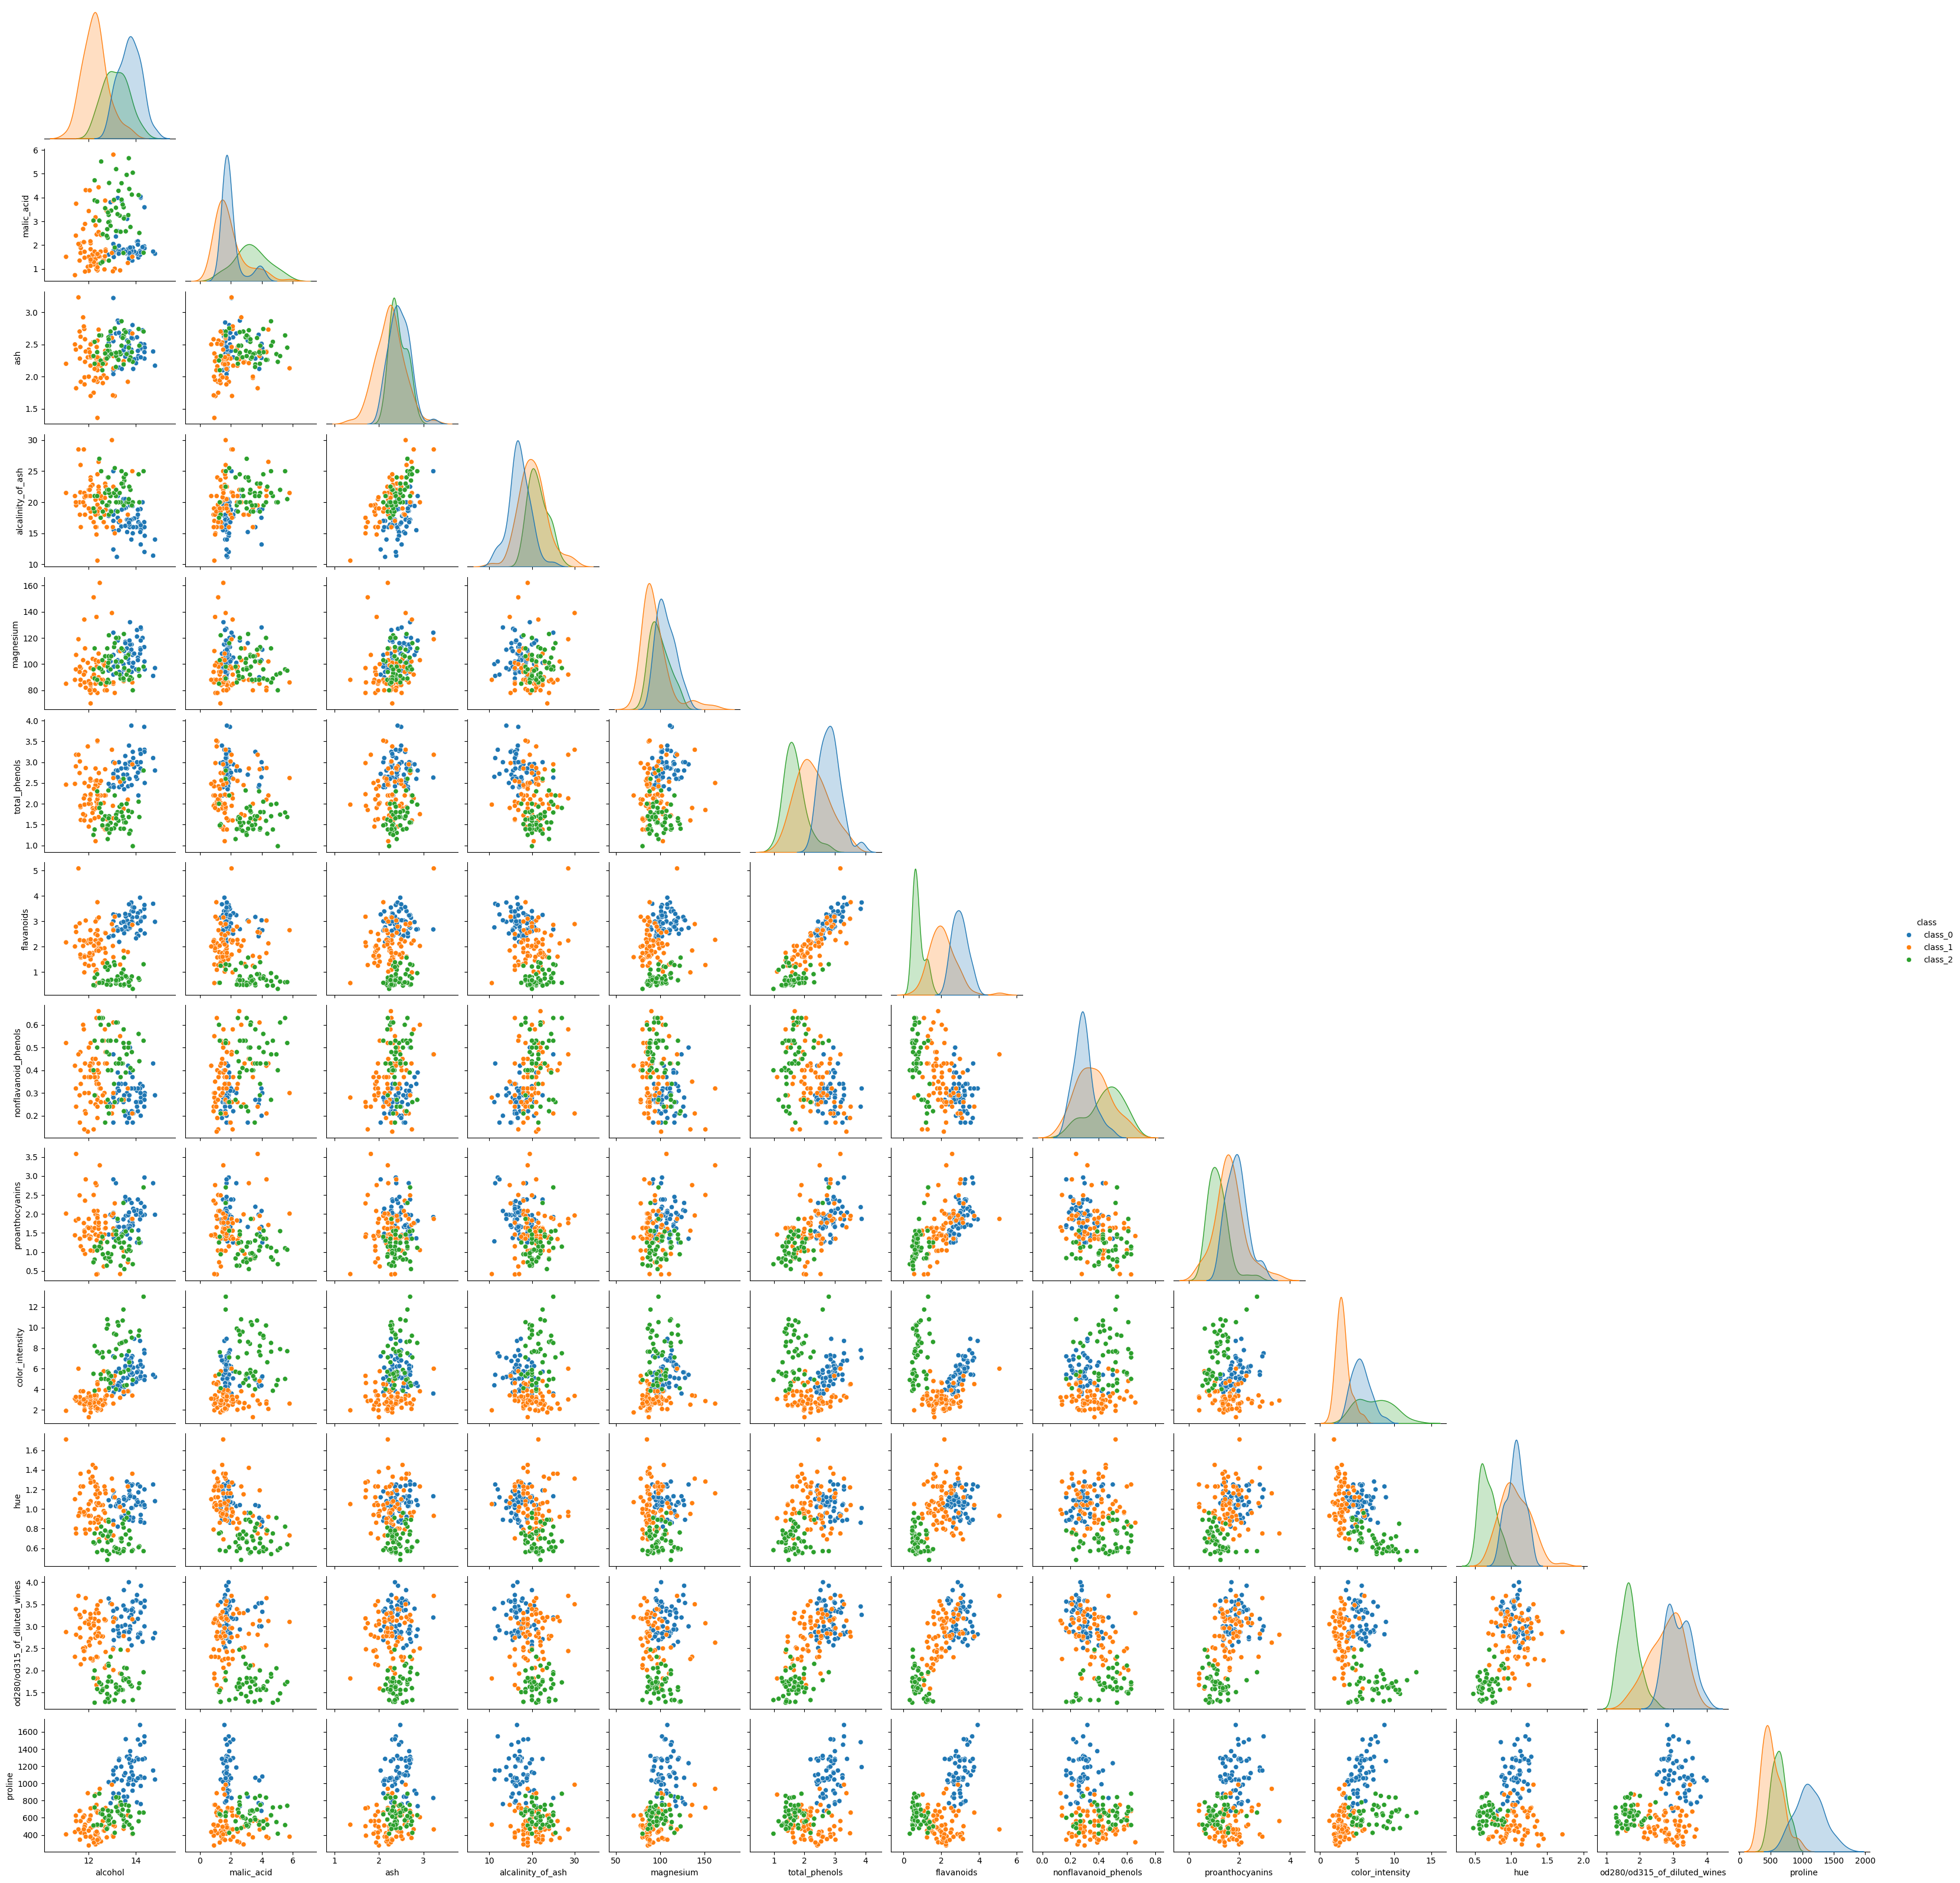

In [ ]:
# Giải thích: Xem kích thước, kiểu dữ liệu và biểu đồ phân phối
# Viết code của bạn tại đây

print(df.info())
print(df.describe())
sns.pairplot(df, hue='class', corner=True)
plt.show()

## Q4. Split the data into training and testing sets

**Question:** Split the data into 80% for training and 20% for testing.

In [6]:
# Giải thích: Chia dữ liệu huấn luyện / kiểm thử bằng train_test_split
# Viết code của bạn tại đây

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Training size: (142, 13)
Testing size: (36, 13)


## Q5. Train a Naïve Bayes model

**Question:** Create a Naïve Bayes classifier using `GaussianNB` and train it on the training data.

In [7]:
# Giải thích: GaussianNB dùng cho dữ liệu liên tục như các thuộc tính của rượu vang
# Viết code của bạn tại đây

model = GaussianNB()
model.fit(X_train, y_train)

print('Model training completed.')

Model training completed.


## Q6. Evaluate the model

**Question:** Predict the classes for the test set and print the classification report.

In [8]:
# Giải thích: Đánh giá mô hình dựa trên các chỉ số precision, recall, f1-score
# Viết code của bạn tại đây
# Dự đoán kết quả
y_pred = model.predict(X_test)
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



## Q7. Plot the confusion matrix

**Question:** Plot the confusion matrix using a heatmap to visualize model performance.

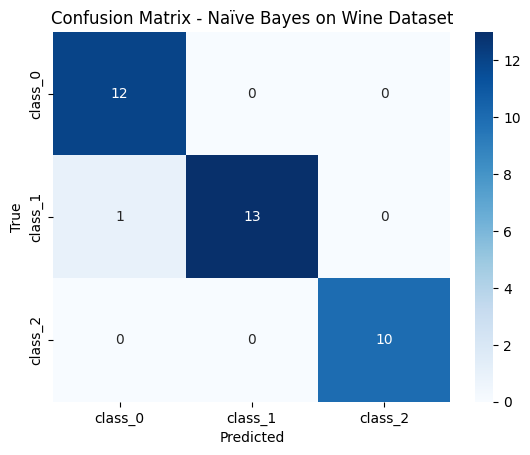

In [9]:
# Giải thích: Ma trận nhầm lẫn giúp xem mô hình dự đoán nhầm giữa các lớp nào
# Viết code của bạn tại đây

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Naïve Bayes on Wine Dataset')
plt.show()

## Q8. Discuss the results

**Question:** Based on the confusion matrix and metrics, discuss how well the Naïve Bayes model performed on the Wine dataset.

**Write your short conclusion below:**

(Gợi ý: Nhận xét về độ chính xác, lỗi phân lớp, và các lớp dễ nhầm lẫn.)

- Mô hình Naïve Bayes cho kết quả chính xác khá cao trên Wine dataset.
- **Độ chính xác (Accuracy):** Mô hình đạt độ chính xác tổng thể là 97%, cho thấy nó phân loại đúng phần lớn các mẫu trong tập kiểm thử.
- **Báo cáo phân loại (Classification Report):**
    - **Precision, Recall, F1-score:** Các chỉ số này đều rất cao (trên 0.9) cho cả ba lớp (`class_0`, `class_1`, và `class_2`), chứng tỏ mô hình hoạt động tốt trong việc xác định từng lớp và giảm thiểu cả lỗi dương tính giả (false positives) và âm tính giả (false negatives).
    - **Support:** Số lượng mẫu trong mỗi lớp trong tập kiểm thử được hiển thị (12 cho class_0, 14 cho class_1, 10 cho class_2).
- **Ma trận nhầm lẫn (Confusion Matrix):**
    - Ma trận cho thấy số lượng dự đoán đúng và sai cho từng lớp.
    - Có 1 mẫu của `class_1` bị dự đoán nhầm thành `class_0`.
    - Tất cả các mẫu của `class_0` và `class_2` đều được dự đoán đúng 100%.
- **Các lớp dễ nhầm lẫn:** Chỉ có sự nhầm lẫn nhỏ giữa `class_0` và `class_1`, với 1 mẫu `class_1` bị phân loại sai là `class_0`. Các lớp còn lại được phân loại rất tốt.

**Kết luận:** Nhìn chung, mô hình Naïve Bayes (GaussianNB) hoạt động xuất sắc trên bộ dữ liệu Wine, đạt độ chính xác cao và chỉ có rất ít lỗi phân loại, chủ yếu giữa `class_0` và `class_1`.